In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = [1, 2, 3, 4, 5]
g = [3, 2, 1]
h = np.convolve(f, g)
h2 = np.correlate(f, g, mode="full")
print(h)
print(h2)

[ 3  8 14 20 26 14  5]
[ 1  4 10 16 22 22 15]


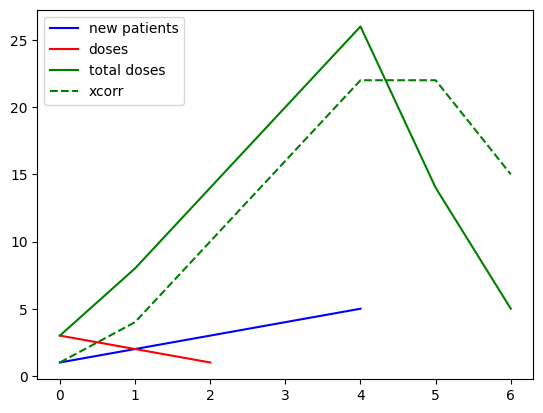

In [3]:
plt.plot(f, 'b', label='new patients')
plt.plot(g, 'r', label='doses')
plt.plot(np.arange(len(h)), h, 'g', label='total doses')
plt.plot(np.arange(len(h2)), h2, 'g--', label="xcorr")
plt.legend()

## Images as 2D (multi-channel) signals

(427, 640, 3)


Text(0.5, 0, 'Blue Channel')

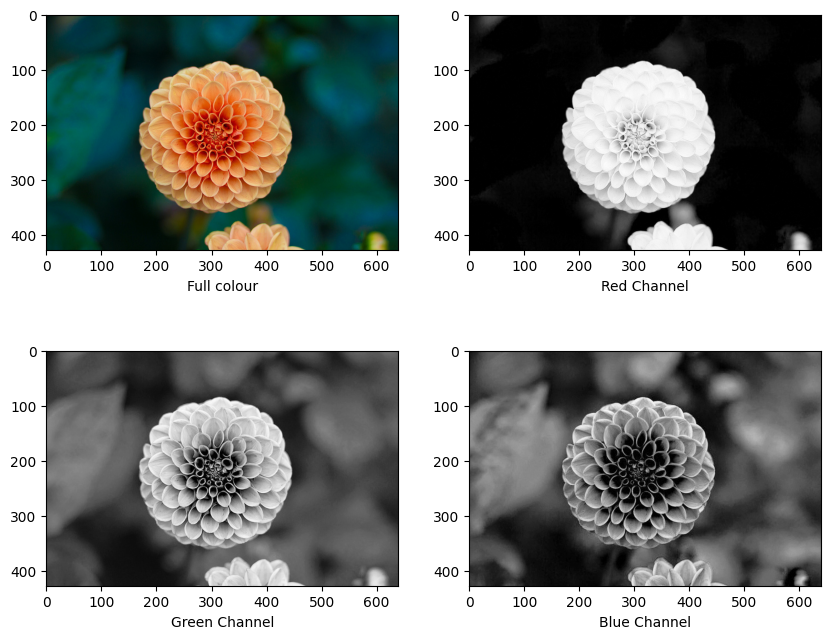

In [4]:
# grab some sample images
from sklearn import datasets
flower = datasets.load_sample_image('flower.jpg')

# Convert to floating point and normalize
flower = flower / 255

fig, ax = plt.subplots(2, 2, figsize=(10,8))
print(flower.shape)
ax[0, 0].imshow(flower)
ax[0, 0].set_xlabel("Full colour")
ax[0, 1].imshow(flower[:,:,0], cmap='Greys_r')
ax[0, 1].set_xlabel("Red Channel")
ax[1, 0].imshow(flower[:,:,1], cmap='Greys_r')
ax[1, 0].set_xlabel("Green Channel")
ax[1, 1].imshow(flower[:,:,2], cmap='Greys_r')
ax[1, 1].set_xlabel("Blue Channel")

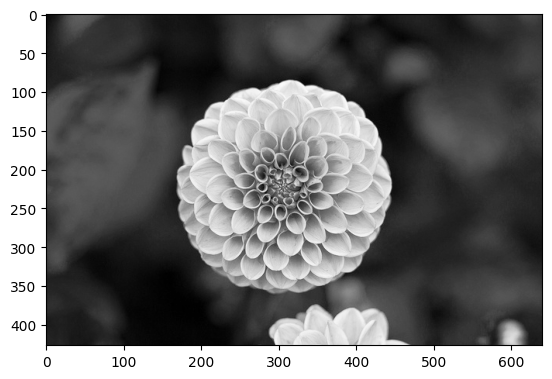

In [5]:
# Take the average of the colour channels to create our greyscale image
flower_g = np.mean(flower, axis=2)
plt.imshow(flower_g, cmap='Greys_r')

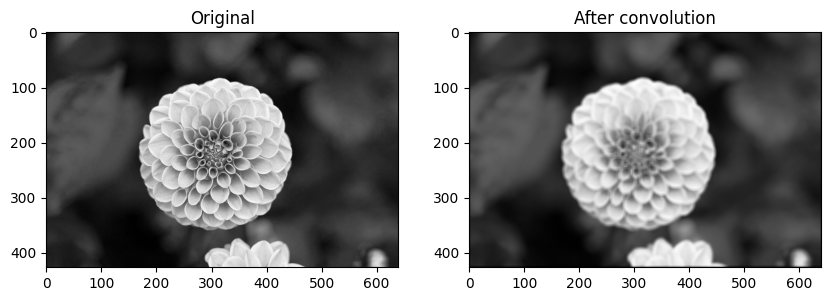

In [6]:
from scipy import signal
# Define a convolution kernel
N = 7
k = np.ones((N, N))

# Normalise the kernel
k = k / N**2

# Convolve it!
flower_conv = signal.convolve2d(flower_g, k, mode='same')

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].set_title("Original")
ax[0].imshow(flower_g, cmap='Greys_r')
ax[1].set_title("After convolution")
ax[1].imshow(flower_conv, cmap='Greys_r')

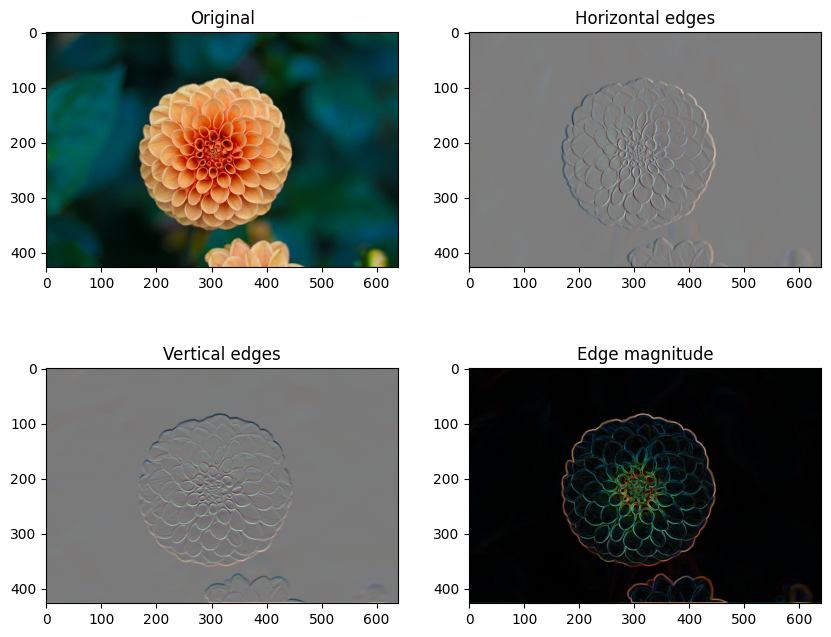

In [7]:
# Sobel kernel - vertical edge detection
k = np.array([[-1, 0, 1],
              [-2, 0, 2],
              [-1, 0, 1]])

# convolution across colour channels
h = np.zeros_like(flower)
v = np.zeros_like(flower)
mag = np.zeros_like(flower)

for i in range(3):
    h[:,:,i] = signal.convolve2d(flower[:,:,i], k, mode='same')
    v[:,:,i] = signal.convolve2d(flower[:,:,i], k.T, mode='same')
    mag[:,:,i] = np.sqrt(h[:,:,i]**2 + v[:,:,i]**2)

# rescale to 0-1
h = (h - h.min()) / (h.max() - h.min())
v = (v - v.min()) / (v.max() - v.min())
mag = (mag - mag.min()) / (mag.max() - mag.min())


fig, ax = plt.subplots(2, 2, figsize=(10,8))
ax[0,0].set_title("Original")
ax[0,0].imshow(flower)
ax[0,1].set_title("Horizontal edges")
ax[0,1].imshow(h)
ax[1,0].set_title("Vertical edges")
ax[1,0].imshow(v)
ax[1,1].set_title("Edge magnitude")
ax[1,1].imshow(mag)

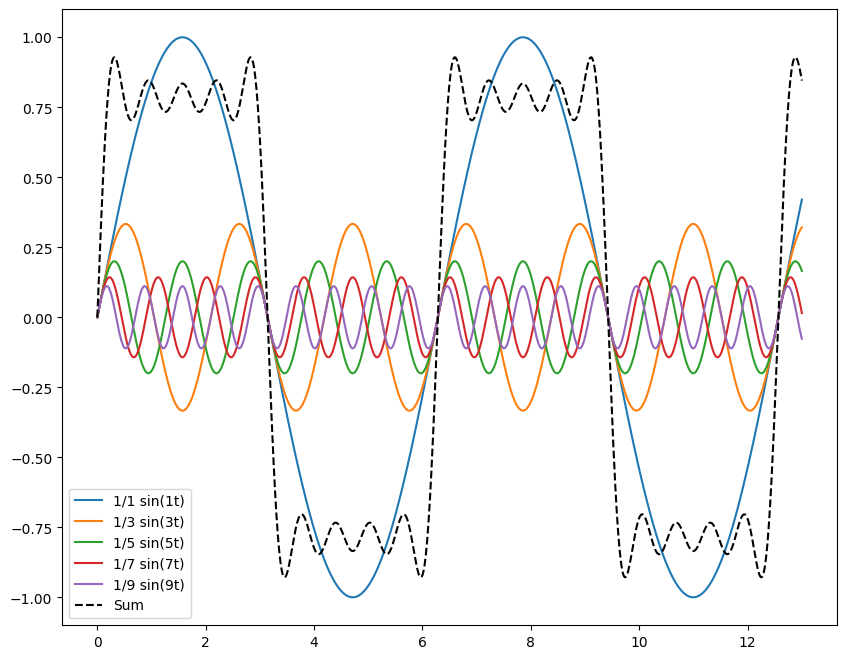

In [8]:
# Fourier example
L = 1024
t = np.linspace(0, 13, 1024)
f = np.zeros_like(t)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for n in range(1, 10, 2):
    freq = (1 / n) * np.sin(t * n)
    ax.plot(t, freq, label=f"1/{n} sin({n}t)")
    f += freq

ax.plot(t, f, "k--", label="Sum")
plt.legend()
plt.show()

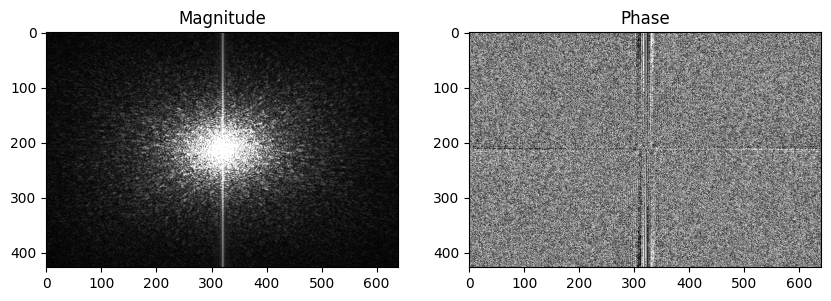

In [9]:
# Frequency domain version
flower_f = np.fft.fft2(flower_g)
flower_f_shifted = np.fft.fftshift(flower_f)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].set_title("Magnitude")
mag_img = ax[0].imshow(np.abs(flower_f_shifted), cmap="grey")
mag_img.set_clim(0, 100)
ax[1].set_title("Phase")
phase_img = ax[1].imshow(np.angle(flower_f_shifted), cmap="grey")
phase_img.set_clim(-np.pi / 2, np.pi / 2)

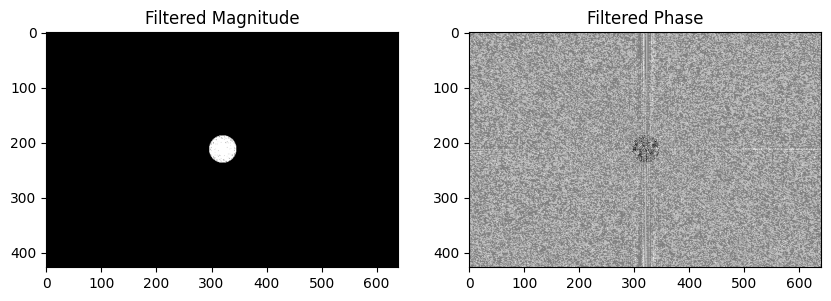

In [10]:
# Create a low-pass filter
max_freq = 50
rows, cols = flower_f.shape
cr, cc = rows // 2, cols // 2

# zeros, except 1s at the centre
low_pass_filter = np.zeros_like(flower_f)
X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
cdist = (Y - cr)**2 + (X - cc)**2
low_pass_filter[cdist < (max_freq / 2)**2] = 1

# multiply in frequency domain
low_f_flower = flower_f_shifted * low_pass_filter
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title("Filtered Magnitude")
mag_filtered_img = ax[0].imshow(np.abs(low_f_flower), cmap="grey")
mag_filtered_img.set_clim(0, 100)

ax[1].set_title("Filtered Phase")
phase_filtered_img = ax[1].imshow(np.angle(low_f_flower), cmap="grey")
phase_filtered_img.set_clim(-np.pi / 2, np.pi / 2)
plt.show()

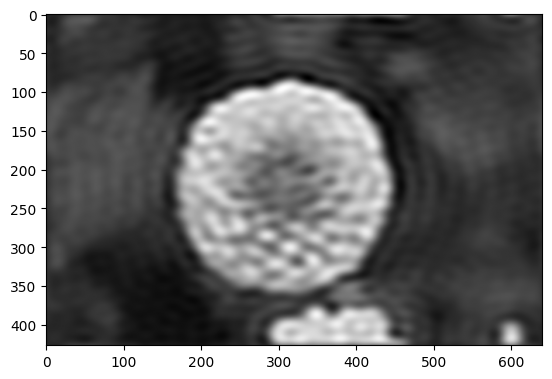

In [11]:
# Inverse FFT of the filtered image
plt.imshow(np.real(np.fft.ifft2(np.fft.ifftshift(low_f_flower))), cmap="grey")


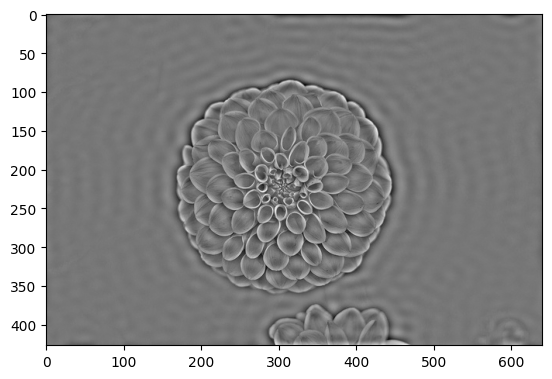

In [12]:
# High frequency version
high_f_flower = flower_f_shifted * (1 - low_pass_filter)
plt.imshow(np.real(np.fft.ifft2(np.fft.ifftshift(high_f_flower))), cmap="grey")


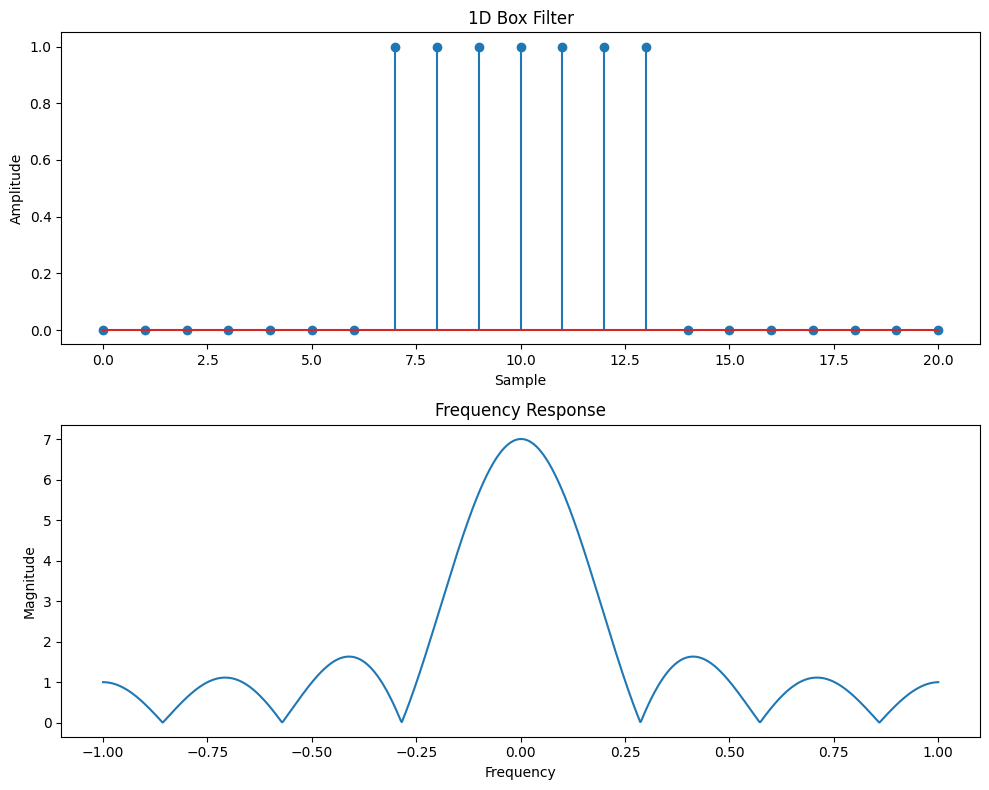

In [13]:
# Define the 1D box filter
box = np.zeros(N * 3)
box[N : N * 2] = 1

# Compute the frequency response of the box filter
n_freqs = 1024
freq_x = np.linspace(-1, 1, n_freqs)
box_freq = np.fft.fftshift(np.fft.fft(box, n_freqs))

# Plot the box filter and its frequency response
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Plot the box filter
ax[0].stem(box)
ax[0].set_title("1D Box Filter")
ax[0].set_xlabel("Sample")
ax[0].set_ylabel("Amplitude")

# Plot the frequency response
ax[1].plot(freq_x, np.abs(box_freq))
ax[1].set_title("Frequency Response")
ax[1].set_xlabel("Frequency")
ax[1].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

## Convolutional Neural Network for Image Classification
We're going to use the [Fashion MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) to try out a simple classification model. This dataset is intended as a "drop-in replacement" for the original MNIST dataset, and it has the same dimensions and number of classes. MNIST has been deemed "too easy", so Fashion MNIST was created to provide more room for improvement.

Example code based on the [Chapter 12 (PyTorch)](https://github.com/ageron/handson-mlp/blob/main/12_deep_computer_vision_with_cnns.ipynb) or [Chapter 14 (Tensorflow)](https://github.com/ageron/handson-ml3/blob/main/14_deep_computer_vision_with_cnns.ipynb) notebook from the Scikit-learn book.

In [15]:
import torch
import torch.nn as nn
import torchmetrics
from functools import partial
from torch.utils.data import DataLoader

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("device =", device)

device = cpu


First, let's set up the dataloader and load the MNIST data

In [16]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

100.0%
100.0%
100.0%
100.0%


A typical CNN has a series of convolution/pooling layers, followed by some fully connected layers leading to the final output layer.

`functools` provides a handy method to define a `partial` function with some default arguments, allowing us to re-use the same layer in each conv2d layer.

In [17]:
torch.manual_seed(42)  # extra code – ensure reproducibility
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")

model = nn.Sequential(
    DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
    DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
    DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=2304, out_features=128), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)

Pytorch needs us to set up our training and evaluation functions

In [18]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, save_path):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
        # save the weights every epoch
        torch.save(model.state_dict(), save_path)
    return history

Finally we can define the optimizer and run the actual training loop

In [21]:
save_path = Path("cnn_weights.pt")


if save_path.exists():
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
else:
    n_epochs = 20
    optimizer = torch.optim.AdamW(model.parameters())
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
    history = train(model, optimizer, xentropy, accuracy,
                    train_loader, valid_loader, n_epochs, save_path)

Epoch 1/20, train loss: 0.5289, train metric: 0.8116, valid metric: 0.8570
Epoch 2/20, train loss: 0.4356, train metric: 0.8503, valid metric: 0.8796
Epoch 3/20, train loss: 0.3839, train metric: 0.8692, valid metric: 0.8890
Epoch 4/20, train loss: 0.3447, train metric: 0.8828, valid metric: 0.8924
Epoch 5/20, train loss: 0.3270, train metric: 0.8881, valid metric: 0.8918
Epoch 6/20, train loss: 0.3064, train metric: 0.8965, valid metric: 0.8848
Epoch 7/20, train loss: 0.2877, train metric: 0.9017, valid metric: 0.8994
Epoch 8/20, train loss: 0.2714, train metric: 0.9070, valid metric: 0.8944
Epoch 9/20, train loss: 0.2624, train metric: 0.9114, valid metric: 0.9016
Epoch 10/20, train loss: 0.2502, train metric: 0.9137, valid metric: 0.8998
Epoch 11/20, train loss: 0.2374, train metric: 0.9190, valid metric: 0.9072
Epoch 12/20, train loss: 0.2244, train metric: 0.9223, valid metric: 0.9138
Epoch 13/20, train loss: 0.2162, train metric: 0.9264, valid metric: 0.9140
Epoch 14/20, train lo

In [22]:
# say we're happy enough with the validation result, let's look at test
evaluate_tm(model, test_loader, accuracy)

tensor(0.9060)

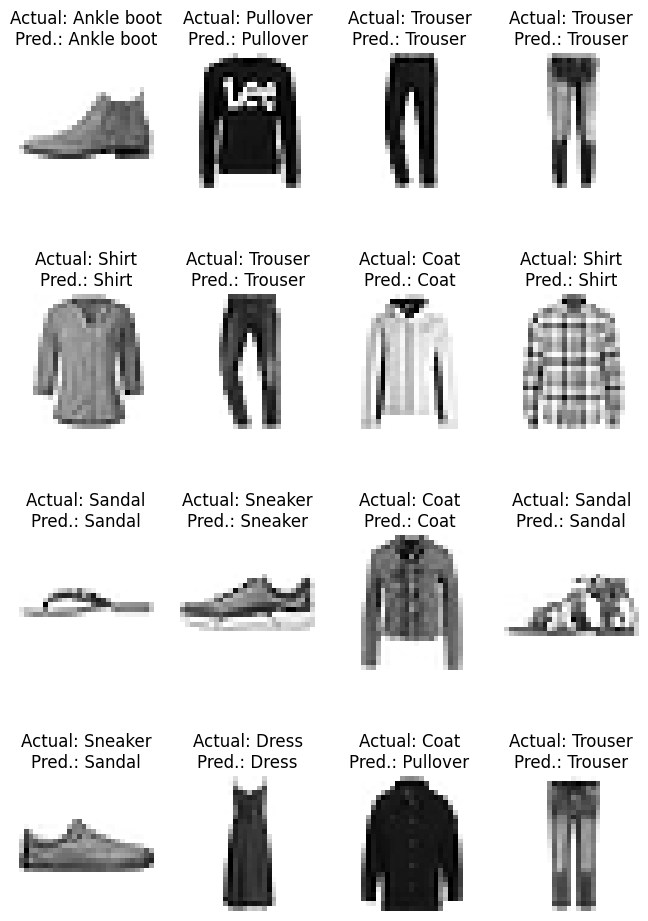

In [23]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
            "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# make sure we're in inference mode
model.eval()
X_test = torch.Tensor()
y_test = torch.Tensor()
y_pred = torch.Tensor()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        pred_batch = model(X_batch)
        X_test = torch.cat([X_test, X_batch])
        y_test = torch.cat([y_test, y_batch])
        y_pred = torch.cat([y_pred, pred_batch])

# plot the first batch of test images along with their predicted label
fig, axes = plt.subplots(4, 4, figsize=(8,12))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_test[i].reshape(28, 28), cmap="binary")
    ax.axis('off')
    actual_label = class_names[int(y_test[i])]
    predicted_label = class_names[np.argmax(y_pred[i])]
    ax.set_title(f"Actual: {actual_label}\nPred.: {predicted_label}")
plt.show()

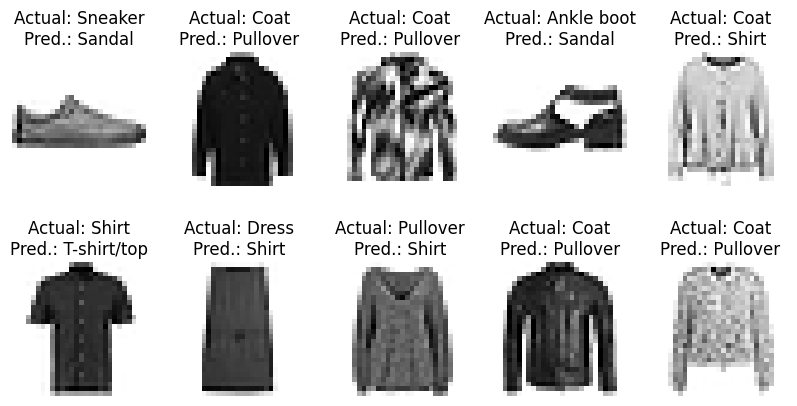

In [42]:
# now plot the first 10 misclassified images
mismatches = np.where(y_test != np.argmax(y_pred, axis=1))[0]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    m  = mismatches[i]
    ax.imshow(X_test[m].reshape(28, 28), cmap="binary")
    ax.axis('off')
    actual_label = class_names[int(y_test[m])]
    predicted_label = class_names[np.argmax(y_pred[m])]
    ax.set_title(f"Actual: {actual_label}\nPred.: {predicted_label}")
plt.show()

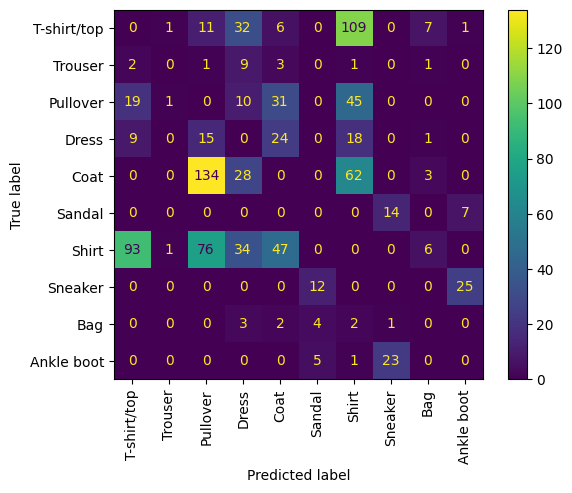

In [43]:
# Look at the confusion matrix to see which classes are being confused
# Only look at the mismatches
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test[mismatches], np.argmax(y_pred, axis=1)[mismatches])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=90)